# 01 Exploration

**Project:** ECG Arrhythmia Classification with MIT-BIH  
**Author:** Qide Zhengzhao  
**Date:** 09 July 2026  

--- 

## Objective of this notebook

This notebook presents a systematic exploratory analysis of the MIT-BIH Arrhythmia Database. Its primary goal is to characterize the ECG recordings, the annotation scheme, heartbeat class distribution, and inter-patient variability before any preprocessing, feature extraction, or machine learning is performed.

Instead of focusing on model development, this notebook establishes a detailed understanding of the dataset that will guide all subsequent design decisions in the project. The analyses documented here are intended to be reproducible and directly traceable to the source records and annotations.

## Why this notebook is necessary

Exploratory analysis is treated as a mandatory engineering step rather than a preliminary formality. Models built without careful data inspection frequently suffer from subtle but critical flaws, such as:

- Using the wrong ECG lead or channel.

- Misinterpreting annotation symbols and clinical meaning.

- Ignoring outlier records, signal quality issues, or class imbalance.

Every decision made in later notebooks (segmentation, labeling, feature design, and model evaluation) is grounded in the results obtained here. By making these choices explicit, the notebook serves as both a technical logbook and a scientific justification for the final classification pipeline.



## Inputs 
The analysis uses WFDB records composed of `.hea`, `.dat` , and `.atr` files. 

- The waveform is read from the binary signal files (`.dat`).

- Metadata is retrieved from the header files (`.hea`).

- Beat annotations and symbols are loaded from the annotation files (`.atr`).

**Sections:**
1. Clinical background — what is an ECG and why does arrhythmia detection matter?
2. Dataset overview — structure, provenance, and annotation quality
3. Imports and setup
4. Loading and inspecting a single record
5. Visualizing the ECG signal and its components
6. Morphological comparison of beat types
7. Class distribution across all 48 records
   - 7.1 Global distribution
   - 7.2 Per-record composition (heatmap)
8. Inter-patient variability
9. Signal quality assessment
10. R-R interval analysis
11. Summary of findings and implications for preprocessing




---
## 1. Clinical Background

### What is an ECG?

The electrocardiogram (ECG) is a non-invasive recording of the heart's electrical activity over time, measured by electrodes placed on the skin. Each heartbeat produces a characteristic waveform whose components reflect the sequence of depolarization and repolarization in the atria and ventricles.

- **P wave:** atrial depolarization, which initiates atrial contraction and ventricular filling.

- **QRS complex:** ventricular depolarization, the largest and most distinctive feature, corresponding to ventricular contraction and blood ejection.

- **T wave:** ventricular repolarization, representing electrical recovery of the ventricles before the next beat.

- **PR interval**: conduction time from atrial depolarization to ventricular activation through the atrioventricular (AV) node and His–Purkinje system.

- **QT interval**: total duration of ventricular depolarization and repolarization.

From an engineering perspective, these components define the temporal structure and morphology that any arrhythmia classifier must preserve during preprocessing and segmentation. Misalignment or distortion of the P wave, QRS complex, or T wave can directly degrade the clinical validity of downstream features.



### What is an arrhythmia?

An arrhythmia is a disturbance in the timing, origin, or conduction of cardiac electrical impulses. Arrhythmias range from clinically benign premature atrial contractions to life-threatening rhythms such as sustained ventricular tachycardia or ventricular fibrillation. 

The heartbeat types most relevant to this project include:


| Type | Clinical name | Mechanism | Clinical significance |
|---|---|---|---|
| **PVC** | Premature Ventricular Contraction | Ectopic focus in ventricle fires prematurely | Can trigger ventricular tachycardia or fibrillation in susceptible patients. |
| **PAC** | Premature Atrial Contraction | Ectopic focus in atrium fires prematurely | Usually benign, but can trigger atrial fibrillation |
| **LBBB** | Left Bundle Branch Block | Conduction delay in left bundle | Suggests underlying structural heart disease. |
| **RBBB** | Right Bundle Branch Block | Conduction delay in right bundle | May be benign or associated with cardiopulmonary disease. |

Although the MIT-BIH annotations are beat-based, these rhythm disturbances reflect underlying electrophysiological mechanisms, such as ectopic pacemaker activity and conduction block. Understanding those mechanisms is essential when interpreting misclassifications and designing clinically meaningful evaluation metrics.

### Why automated detection matters

Manual ECG interpretation requires trained cardiologists, which introduces unavoidable bottlenecks in several real-world scenarios:

- Long-term Holter recordings (24–48 hours) generate thousands of beats that cannot be reviewed exhaustively.

- Emergency settings require rapid triage, often without immediate access to electrophysiology expertise.

- Wearable devices (smartwatches, patches) produce continuous streams of ECG data outside hospital environments.

Automated arrhythmia classifiers can pre-screen recordings and flag abnormal beats or episodes for physician review, reducing workload and enabling earlier intervention. In this context, the MIT-BIH Arrhythmia Database provides a controlled benchmark on which engineering decisions can be tested before translation to more heterogeneous clinical data.

---
## 2. Dataset Overview

### The MIT-BIH Arrhythmia Database

The MIT-BIH Arrhythmia Database was developed at the MIT-BIH Arrhythmia Laboratory between 1975 and 1979 and later distributed via PhysioNet. It is one of the most widely used benchmarks for ECG beat classification and heart rhythm analysis, and has been cited in hundreds of peer-reviewed publications.

Key characteristics include:

- 48 two-channel ambulatory ECG recordings.

- Recording duration: 30 minutes per record.

- Sampling frequency: 360 Hz (360 samples per second).

- Amplitude resolution: 11 bits over a 5 mV range.

- Approximately 110,000 annotated beats in total.

- Annotations made independently by two or more cardiologists, with disagreements resolved by consensus.

The double-annotation procedure is important technically as well as clinically. It implies that the beat labels represent expert consensus rather than a single annotator, which reduces label noise and justifies treating MIT-BIH as a gold-standard reference for supervised learning.

**Channel configuration**

Each record contains two ECG leads:

- Channel 0: MLII (Modified Limb Lead II), commonly used for arrhythmia detection because it provides a clear view of the P wave and QRS complex.

- Channel 1: V1 or V5 (precordial leads), which offer complementary information; the specific precordial lead varies between records.

In this project, Channel 0 (MLII) is used exclusively for beat segmentation and classification, following the convention adopted in most of the MIT-BIH literature. This choice simplifies the processing pipeline and aligns the work with prior studies, which is important when comparing performance across algorithms.

**Dataset limitations and implications**

The 48 patients in MIT-BIH were selected because their recordings contained interesting arrhythmias. As a result, arrhythmias are intentionally overrepresented relative to their prevalence in the general population. The dataset therefore does not reflect true incidence or case mix in routine clinical practice, a limitation that is explicitly acknowledged in the original publications and subsequent work.

For this project, MIT-BIH is treated as a controlled environment for developing and validating ECG arrhythmia classifiers under well-defined conditions. Any model trained on MIT-BIH must later be evaluated on more representative datasets before clinical deployment, and this notebook takes the first step by making dataset structure and annotation quality fully explicit.

## References

[1] G. B. Moody and R. G. Mark, "The impact of the MIT-BIH Arrhythmia Database," *IEEE Engineering in Medicine and Biology Magazine*, vol. 20, no. 3, pp. 45–50, May–Jun. 2001, doi: 10.1109/51.932724.

[2] A. L. Goldberger, L. A. N. Amaral, L. Glass, J. M. Hausdorff, P. Ch. Ivanov, R. G. Mark, J. E. Mietus, G. B. Moody, C.-K. Peng, and H. E. Stanley, "PhysioBank, PhysioToolkit, and PhysioNet: Components of a New Research Resource for Complex Physiologic Signals," *Circulation*, vol. 101, no. 23, pp. e215–e220, Jun. 2000, doi: 10.1161/01.CIR.101.23.e215.

[3] G. B. Moody and R. G. Mark, "MIT-BIH Arrhythmia Database," PhysioNet. [Online]. Available: https://physionet.org/content/mitdb/. [Accessed: 28-Jun-2026].

---
## 3. Imports and Setup

The original MIT-BIH annotations cover a large number of heartbeat types and auxiliary symbols. Following the AAMI EC57 recommendation, we group these into five clinically meaningful categories: N, S, V, F, and Q.






<table style="border-collapse: collapse; width:100%;">

<tr style="background-color:#EAEAEA;">
    <th style="border:1px solid #CCC; padding:8px; color:black;">AAMI Class</th>
    <th style="border:1px solid #CCC; padding:8px; color:black;">Full name</th>
    <th style="border:1px solid #CCC; padding:8px; color:black;">Description</th>
</tr>

<tr style="background-color:#3B82F6;">
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>N</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Normal beat</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Normal sinus rhythm beats</td>
</tr>

<tr style="background-color:#F59E0B;">
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>S</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Supraventricular ectopic beat</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Atrial or junctional premature beats</td>
</tr>

<tr style="background-color:#EF4444;">
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>V</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Ventricular ectopic beat (PVC / escape)</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Premature ventricular contractions or ventricular escape beats</td>
</tr>

<tr style="background-color:#8B5CF6;">
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>F</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Fusion beat</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Combination of normal and ventricular activity</td>
</tr>

<tr style="background-color:#FF06FB;">
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>Q</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Unknown / paced / unclassifiable beat</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Paced beats or non-classifiable signals</td>
</tr>

</table>

This standardized mapping is widely adopted in the ECG classification literature and enables direct comparison with previously published work. In practice, the mapping is implemented as a lookup table (AAMIMAP) that converts original MIT-BIH symbols (such as N, L, R, V, F, Q, etc.) to one of the five AAMI classes.


<table style="border-collapse: collapse; width:100%;">

<tr style="background-color:#EAEAEA;">
    <th style="border:1px solid #CCC; padding:8px; color:black;">Original label</th>
    <th style="border:1px solid #CCC; padding:8px; color:black;">AAMI class</th>
    <th style="border:1px solid #CCC; padding:8px; color:black;">Meaning</th>
</tr>

<!-- N -->
<tr style="background-color:#3B82F6;">
    <td style="border:1px solid #CCC; padding:8px; color:black;">N</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>N</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Normal beat</td>
</tr>

<tr style="background-color:#3B82F6;">
    <td style="border:1px solid #CCC; padding:8px; color:black;">L</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>N</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Left bundle branch block beat</td>
</tr>

<tr style="background-color:#3B82F6;">
    <td style="border:1px solid #CCC; padding:8px; color:black;">R</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>N</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Right bundle branch block beat</td>
</tr>

<tr style="background-color:#3B82F6;">
    <td style="border:1px solid #CCC; padding:8px; color:black;">e</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>N</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Atrial escape beat</td>
</tr>

<tr style="background-color:#3B82F6;">
    <td style="border:1px solid #CCC; padding:8px; color:black;">j</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>N</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Nodal (junctional) escape beat</td>
</tr>

<!-- S -->
<tr style="background-color:#F59E0B;">
    <td style="border:1px solid #CCC; padding:8px; color:black;">A</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>S</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Atrial premature beat</td>
</tr>

<tr style="background-color:#F59E0B;">
    <td style="border:1px solid #CCC; padding:8px; color:black;">a</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>S</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Aberrated atrial premature beat</td>
</tr>

<tr style="background-color:#F59E0B;">
    <td style="border:1px solid #CCC; padding:8px; color:black;">J</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>S</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Junctional premature beat</td>
</tr>

<tr style="background-color:#F59E0B;">
    <td style="border:1px solid #CCC; padding:8px; color:black;">S</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>S</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Supraventricular premature beat</td>
</tr>

<!-- V -->
<tr style="background-color:#EF4444;">
    <td style="border:1px solid #CCC; padding:8px; color:black;">V</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>V</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Premature ventricular contraction (PVC)</td>
</tr>

<tr style="background-color:#EF4444;">
    <td style="border:1px solid #CCC; padding:8px; color:black;">E</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>V</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Ventricular escape beat</td>
</tr>

<!-- F -->
<tr style="background-color:#8B5CF6;">
    <td style="border:1px solid #CCC; padding:8px; color:black;">F</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>F</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Fusion beat</td>
</tr>

<!-- Q -->
<tr style="background-color:#FF06FB;">
    <td style="border:1px solid #CCC; padding:8px; color:black;">/</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>Q</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Paced beat</td>
</tr>

<tr style="background-color:#FF06FB;">
    <td style="border:1px solid #CCC; padding:8px; color:black;">f</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>Q</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Fusion of paced and normal beat</td>
</tr>

<tr style="background-color:#FF06FB;">
    <td style="border:1px solid #CCC; padding:8px; color:black;">Q</td>
    <td style="border:1px solid #CCC; padding:8px; color:black;"><b>Q</b></td>
    <td style="border:1px solid #CCC; padding:8px; color:black;">Unclassifiable beat</td>
</tr>

</table>

All symbols not present in `AAMI_MAP` are silently discarded during beat segmentation. This is correct behavior: including them would either add mislabeled beats (artifacts tagged as real beats) or attempt to extract  a fixed-length window around a marker that has no associated QRS complex, producing meaningless signal segments. 

The `+` symbol is by far the most frequent non-beat annotation, it appears at least once in every record to mark the initial rhythm annotation.

| Symbol | Name | What it marks | Why we discard it |
|---|---|---|---|
| `+` | Rhythm change | Start of a new rhythm type (e.g. atrial fibrillation, ventricular tachycardia) | Event marker, not a beat — has no QRS morphology |
| `~` | Signal quality change | Point where signal quality degrades (loose electrode, patient movement) | Not a beat — marks a data quality issue |
| `\|` | Isolated QRS-like artifact | Electrical artifact that resembles a QRS but is not a real heartbeat | False detection — would corrupt the feature space |
| `s` | ST segment change | Marks a change in the ST segment (relevant for ischemia, not arrhythmia classification) | Not a beat type — different clinical domain |
| `T` | T-wave change | Marks a morphological change in the T wave | Not a beat type |
| `*` | Ventricular flutter wave | Individual wave during ventricular flutter | Extremely rare; not segmentable as a standard beat window |
| `D` | Diastolic noise | Noise occurring during diastole | Not a beat |
| `=` | Resumption of ventricular pacing | Pacemaker reactivation event | Event marker, not a beat |
| `"` | Comment | Free-text note written by the annotator | Unstructured text, unclassifiable |
| `x` | Non-conducted P-wave | P wave with no following QRS (high-degree AV block) | No ventricular activation — no QRS to segment |
| `!` | Ventricular flutter | Start of a ventricular flutter episode | Rhythm event, not an individual beat |
| `[` | Start of ventricular flutter/fibrillation | Episode start delimiter | Event marker |
| `]` | End of ventricular flutter/fibrillation | Episode end delimiter | Event marker |
| `p` | P-wave peak | Peak of the P wave (waveform component annotation) | Component label, not a full beat |
| `t` | T-wave peak | Peak of the T wave | Component label, not a full beat |
| `u` | U-wave peak | Peak of the U wave (small wave after T, not always present) | Component label, not a full beat |

The Python environment uses standard scientific libraries (`NumPy`, `pandas`, `matplotlib`) plus `wfdb` for reading PhysioNet-format records and NeuroKit2 for optional signal processing. Global constants define the sampling frequency (`FS = 360 Hz`), data path, full list of record names, and plotting styles, ensuring that all subsequent analyses use consistent settings across the notebook.

In [124]:
import neurokit2 as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import os
import wfdb
from collections import Counter
from scipy.signal import butter, filtfilt
import warnings
warnings.filterwarnings('ignore')

# Consistent plot styling across the notebook ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})
#──────────────────────────────────────────────────────────────────────────────────────────────


# ── Constants ────────────────────────────────────────────────────────────────────────────────
FS          = 360               # Sampling frequency (Hz) — fixed for all MIT-BIH records
DATA_PATH   = '../data/raw/'    # Path to downloaded MIT-BIH files
#──────────────────────────────────────────────────────────────────────────────────────────────


# Auto-detect record names in MIT-BIH ──────────────────────────────────────────────────────────
def get_valid_records(data_path, required_exts=('.hea', '.dat', '.atr')):
    """
    Scans data_path and returns the list of record names that have
    ALL required files (.hea, .dat, .atr).
    Also reports incomplete/discarded records.
    """
    all_files = os.listdir(data_path)

    # Base names of all .hea files found
    candidates = sorted(
        {os.path.splitext(f)[0] for f in all_files if f.endswith('.hea')},
        key=lambda x: int(x) if x.isdigit() else x
    )

    valid_records = []
    incomplete = {}

    for rec in candidates:
        missing = [
            ext for ext in required_exts
            if not os.path.exists(os.path.join(data_path, rec + ext))
        ]
        if missing:
            incomplete[rec] = missing
        else:
            valid_records.append(rec)

    return valid_records, incomplete


ALL_RECORDS, incomplete_records = get_valid_records(DATA_PATH)
#──────────────────────────────────────────────────────────────────────────────────────────────


# AAMI EC57 label mapping and display properties ──────────────────────────────────────────────
AAMI_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',    # Normal beats
    'A':'S','a':'S','J':'S','S':'S',            # Supraventricular ectopic beats
    'V':'V','E':'V',                            # Ventricular ectopic beats (PVCs)
    'F':'F',                                    # Fusion beats
    '/':'Q','f':'Q','Q':'Q'                     # Paced and unclassifiable beats
}
CLASS_COLORS = {
    'N': '#3B82F6',   
    'S': '#F59E0B',   
    'V': '#EF4444',   
    'F': '#8B5CF6',   
    'Q': '#FF06FB'    
}
CLASS_NAMES  = {
    'N':'Normal (N)',
    'S':'Supraventricular ectopic (S)',
    'V':'Ventricular ectopic / PVC (V)',
    'F':'Fusion beat (F)',
    'Q':'Unknown / Paced (Q)'
}
#──────────────────────────────────────────────────────────────────────────────────────────────


# Code Report ─────────────────────────────────────────────────────────────────────────────────
print(f"Dataset path : {DATA_PATH}")
print(f"Total records: {len(ALL_RECORDS)}")
print(f"Sampling freq: {FS} Hz  →  1 sample = {1000/FS:.2f} ms")

if incomplete_records:
    print(f"\n⚠️  {len(incomplete_records)} incomplete record(s) (skipped):")
    for rec, missing in incomplete_records.items():
        print(f"   - {rec}: missing {missing}")
#──────────────────────────────────────────────────────────────────────────────────────────────


Dataset path : ../data/raw/
Total records: 48
Sampling freq: 360 Hz  →  1 sample = 2.78 ms


---
## 4. Loading and Inspecting a Single Record

We begin the exploratory analysis with Record 100, which is one of the simpler recordings: predominantly normal sinus rhythm with occasional premature ventricular contractions (PVCs). This record provides a clean starting point to understand the data structure before dealing with more complex arrhythmia patterns, and the same code can be reused for any other MIT-BIH record by changing a single parameter (`record_num`) in the loading cell.


Using the wfdb library, each MIT-BIH record is loaded from three files:

- `.dat`: binary signal data (the raw ECG waveform).

- `.hea`: header file containing metadata (sampling rate, units, lead names, patient information).

- `.atr`: annotation file with beat labels and sample positions.



For a given record, we first print basic signal metadata: lead names, sampling frequency, number of channels, total number of samples, recording duration, signal units, and signal array shape. We then inspect the annotation metadata: total number of annotations, the set of unique symbols present in the record, and the first few sample positions and symbols.



In [125]:
record_num = '100'

# Load record (the full 30-minute recording) ───────────────────────────────────────────────────────────
record     = wfdb.rdrecord(DATA_PATH + record_num)
annotation = wfdb.rdann(DATA_PATH + record_num, 'atr')
#───────────────────────────────────────────────────────────────────────────────────────────────────────


# Signal metadata ──────────────────────────────────────────────────────────────────────────────────────
print("=" * 55)
print(f"RECORD {record_num} — METADATA")
print("=" * 55)
print(f"Lead names          : {record.sig_name}")
print(f"Sampling frequency  : {record.fs} Hz")
print(f"Number of channels  : {record.n_sig}")
print(f"Total samples       : {record.sig_len}  ({record.sig_len / record.fs / 60:.1f} minutes)")
print(f"Signal units        : {record.units}")
print(f"Signal shape        : {record.p_signal.shape}  (samples × channels)")
print()
#─────────────────────────────────────────────────────────────────────────────────────────────────────────


# Annotation metadata ────────────────────────────────────────────────────────────────────────────────────
print("ANNOTATION FILE — METADATA")
print("=" * 55)
print(f"Total annotations   : {len(annotation.sample)}")
print(f"Unique symbols      : {sorted(set(annotation.symbol))}")
print(f"First 10 positions  : {annotation.sample[:10]}")
print(f"First 10 symbols    : {annotation.symbol[:10]}")
print()
#─────────────────────────────────────────────────────────────────────────────────────────────────────────


# Count raw symbol distribution────────────────────────────────────────────────────────────────────────────
raw_counts = Counter(annotation.symbol)
print("=" * 55)
print(f"RAW SYMBOL DISTRIBUTION (record {record_num})")
print("=" * 55)
for sym, count in sorted(raw_counts.items(), key=lambda x: -x[1]):
    aami = AAMI_MAP.get(sym, '—')
    print(f"  '{sym}'  →  AAMI class '{aami}'  :  {count} beats")
print()
#───────────────────────────────────────────────────────────────────────────────────────────────────────────

RECORD 100 — METADATA
Lead names          : ['MLII', 'V5']
Sampling frequency  : 360 Hz
Number of channels  : 2
Total samples       : 650000  (30.1 minutes)
Signal units        : ['mV', 'mV']
Signal shape        : (650000, 2)  (samples × channels)

ANNOTATION FILE — METADATA
Total annotations   : 2274
Unique symbols      : ['+', 'A', 'N', 'V']
First 10 positions  : [  18   77  370  662  946 1231 1515 1809 2044 2402]
First 10 symbols    : ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']

RAW SYMBOL DISTRIBUTION (record 100)
  'N'  →  AAMI class 'N'  :  2239 beats
  'A'  →  AAMI class 'S'  :  33 beats
  '+'  →  AAMI class '—'  :  1 beats
  'V'  →  AAMI class 'V'  :  1 beats



A simple example (in code) illustrates this process for a 30-minute record and a 10-second excerpt; the output confirms that:

- Sampling frequency is 360 Hz.

- The signal has shape (650000, 2) for a typical 30-minute, two-channel recording.

- Annotation symbols include beat types and non-beat markers, which we later map or discard according to AAMIMAP.

To characterize the annotation scheme in more detail, the notebook computes the raw symbol distribution for the selected record and reports how many times each symbol appears, along with its corresponding AAMI class when applicable. It also converts sample indices into seconds to give a sense of when the first occurrences of each symbol appear in time (e.g., first PVC, first paced beat), which helps build intuition about the temporal structure of arrhythmias in that record.

In [126]:
# ── Timing of non-normal annotations ──────────────────────────────────────
print("=" * 55)
print(f"RAW SYMBOL TIME (record {record_num})")
print("=" * 55)

for sym, count in sorted(raw_counts.items(), key=lambda x: -x[1]):

    if sym == 'N':
        continue

    times = [
        sample / record.fs
        for sample, symbol in zip(annotation.sample, annotation.symbol)
        if symbol == sym
    ]

    aami = AAMI_MAP.get(sym, '—')

    print(f"'{sym}' → AAMI class '{aami}' ({len(times)} beats)")

    if len(times) == 0:
        print("  No occurrences")
    else:
        print("  First occurrences:",
              ", ".join(f"{t:.2f} s" for t in times[:5]))

    print()
# ────────────────────────────────────────────────────────────────────────────

RAW SYMBOL TIME (record 100)
'A' → AAMI class 'S' (33 beats)
  First occurrences: 5.68 s, 185.53 s, 208.29 s, 276.61 s, 355.79 s

'+' → AAMI class '—' (1 beats)
  First occurrences: 0.05 s

'V' → AAMI class 'V' (1 beats)
  First occurrences: 1518.87 s



This level of inspection ensures that we understand the relationship between the waveform, metadata, and annotations before any preprocessing or feature extraction is applied. It also surfaces record-specific quirks, such as unusual symbol usage or atypical annotation densities, that might otherwise cause subtle bugs in downstream segmentation and classification logic.

---
## 5. Visualizing the ECG Signal

A researcher should always inspect the raw waveform before applying preprocessing or building any classifier. In this section, we generate a clean annotated plot of the ECG so that the reader can directly connect the signal morphology with the beat labels provided in the database.

The visualization window is fully configurable in the code: the user can easily change both the start time and the duration of the segment by modifying a couple of simple parameters (`t_start_s` and `t_end_s`). This means the plot is not restricted to 10 seconds, nor does it need to begin at a fixed instant; the same code can be used to inspect shorter or longer intervals, starting at any point within the recording.

In our case, we visualize Record 100 over a 10-second interval from 60 to 70 seconds, marking each annotated beat with a vertical line colored according to its AAMI class. In many cases, these classes also show visibly different morphologies, but this visual distinction is not consistent across all records and patients, so we treat it only as qualitative intuition rather than a formal part of the analysis.

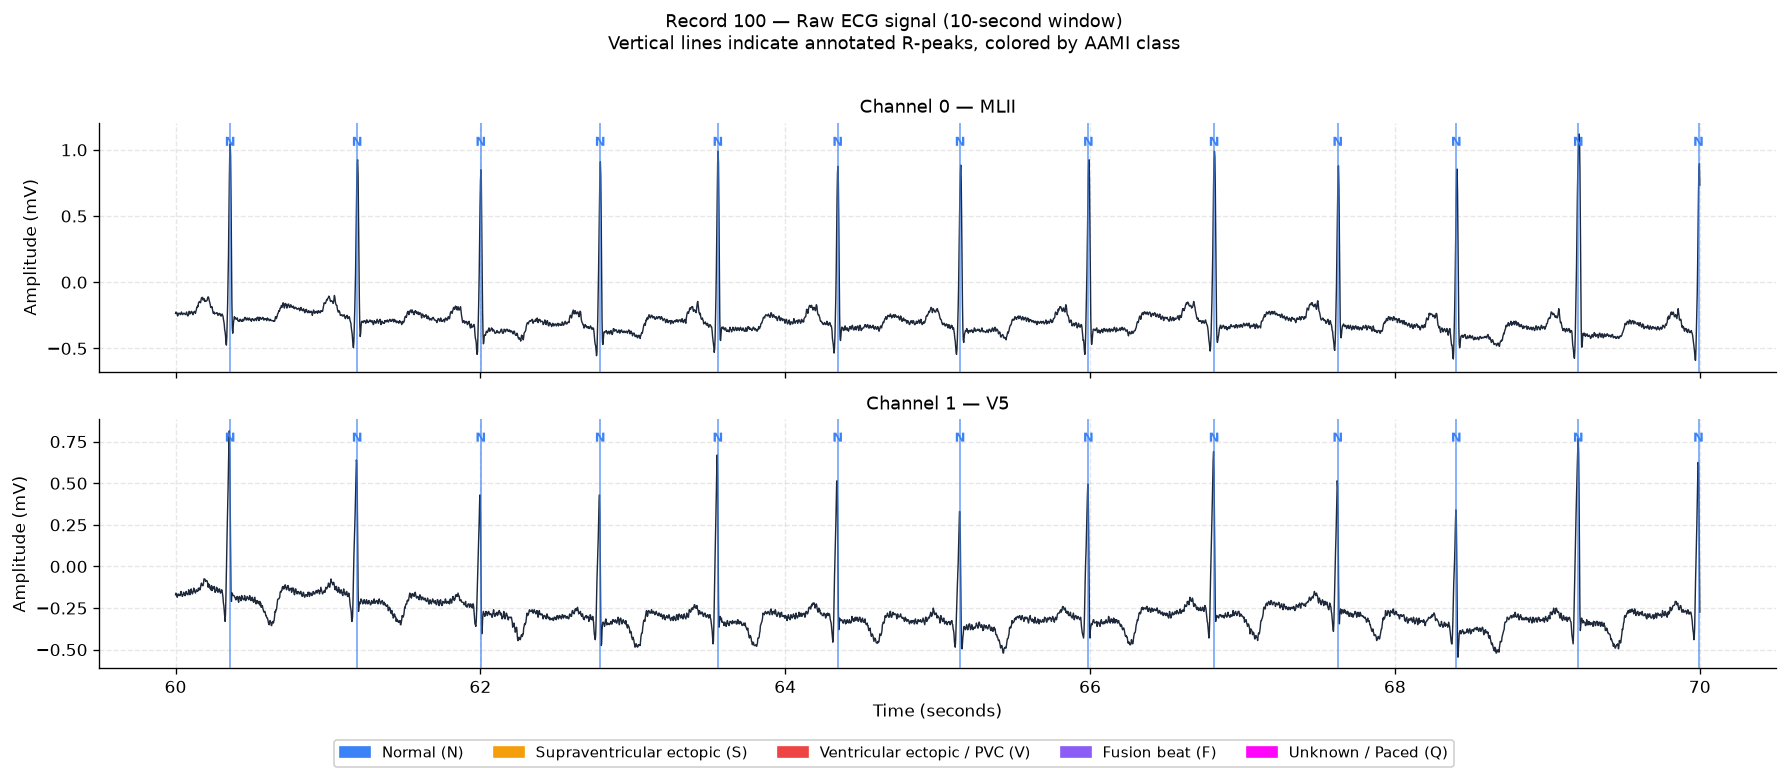

Beats visible in this window: 13
Average R-R interval: 803 ms → heart rate ≈ 75 bpm


In [127]:
#–– Extract 10 seconds of signal for visualization ───────────────────────────────────────────────────────────────────────────────────────────────
t_start_s = 60     # Start at 60 seconds to skip any edge artifacts
t_end_s   = 70     # 10-second window
#───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────––



#–– Input validation ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
record_duration_s = record.sig_len / FS

if t_start_s >= t_end_s:
    raise ValueError(
        f"t_start_s ({t_start_s}s) must be strictly less than "
        f"t_end_s ({t_end_s}s). Please fix the window parameters."
    )

if t_start_s < 0:
    raise ValueError(
        f"t_start_s ({t_start_s}s) cannot be negative."
    )

if t_end_s > record_duration_s:
    raise ValueError(
        f"t_end_s ({t_end_s}s) exceeds record duration "
        f"({record_duration_s:.1f}s). Choose a value within the recording."
    )
#─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


#–– Continue only if previous validation passed ──────────────────────────────────────────────────────────────────────────────────────────────────
s_start   = t_start_s * FS
s_end     = t_end_s   * FS

sig_ch0 = record.p_signal[s_start:s_end, 0]   
sig_ch1 = record.p_signal[s_start:s_end, 1]   
time_s  = np.linspace(t_start_s, t_end_s, s_end - s_start)
#─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────



#–– Filter annotations to this window ────────────────────────────────────────────────────────────────────────────────────────────────────────────
mask = (annotation.sample >= s_start) & (annotation.sample < s_end)
ann_samples = annotation.sample[mask]
ann_symbols = [annotation.symbol[i] for i in range(len(annotation.symbol)) if mask[i]]

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

for ax, sig, lead in zip(axes, [sig_ch0, sig_ch1], [f'Channel 0 — {record.sig_name[0]}', f'Channel 1 — {record.sig_name[1]}']):
    ax.plot(time_s, sig, color='#1E293B', linewidth=0.85, zorder=2)
    
    # Mark each beat with a vertical line colored by AAMI class
    for sample, symbol in zip(ann_samples, ann_symbols):
        aami_class = AAMI_MAP.get(symbol, None)
        if aami_class is None:
            continue
        color = CLASS_COLORS[aami_class]
        ax.axvline(sample / FS, color=color, alpha=0.6, linewidth=1.2, zorder=3)
        
        # Label at top of the plot
        ymax = ax.get_ylim()[1] if ax.get_ylim()[1] != 1.0 else np.max(sig) * 1.1
        ax.text(sample / FS, np.max(sig) * 0.92, symbol,
                fontsize=7.5, ha='center', color=color, fontweight='bold')
    
    ax.set_ylabel('Amplitude (mV)', fontsize=10)
    ax.set_title(lead, fontsize=11)

axes[1].set_xlabel('Time (seconds)', fontsize=10)
#─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────–



#–– Build legend ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────–
legend_patches = [
    mpatches.Patch(color=CLASS_COLORS[c], label=CLASS_NAMES[c])
    for c in ['N', 'S', 'V', 'F', 'Q']
]

fig.legend(
    handles=legend_patches,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),    # centered horizontally, directly below the figure
    ncol=5,                         # everything in one line
    fontsize=9,
    framealpha=0.9
)

fig.suptitle(f'Record {record_num} — Raw ECG signal ({t_window}-second window)\nVertical lines indicate annotated R-peaks, colored by AAMI class',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'../results/figures/01_05_raw_ecg_overview_record_{record_num}.png', bbox_inches='tight')
plt.show()
#─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


#–– Comments ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────–
print(f"Beats visible in this window: {len(ann_samples)}")
print(f"Average R-R interval: {np.mean(np.diff(ann_samples)) / FS * 1000:.0f} ms "
      f"→ heart rate ≈ {60 / (np.mean(np.diff(ann_samples)) / FS):.0f} bpm")
#─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

---
## 6. Morphological Comparison of Beat Types

This section focuses on how the average waveform shape differs across the five AAMI classes. The goal is to build qualitative intuition about which visual features might later become useful mathematical features for classification.

To make the comparison fair, we:
- Center each beat on its annotated R-peak
- Z-score normalize each beat individually (removes amplitude differences between patients)
- Overlay multiple examples per class (in light color) and plot the class mean (in bold)

The variability within each class (spread of the light lines) tells us how difficult the classification problem is.

In [128]:
#── Helper: extract and normalize a beat window ────────────────────────────
def get_beat(signal, r_sample, before=90, after=110):
    """Extract a normalized beat window centered on R-peak."""
    start, end = r_sample - before, r_sample + after
    if start < 0 or end > len(signal):
        return None
    beat = signal[start:end].astype(float)
    std = beat.std()
    if std < 1e-6:
        return None
    return (beat - beat.mean()) / std
#────────────────────────────────────────────────────────────────────────────


#── Collect example beats per AAMI class from multiple records ─────────────–
# We use several records to ensure we capture morphological diversity
SAMPLE_RECORDS = ['100', '106', '119', '200', '208', '213', '217']

beats_by_class = {c: [] for c in ['N', 'S', 'V', 'F', 'Q']}

for rec_name in SAMPLE_RECORDS:
    try:
        rec = wfdb.rdrecord(DATA_PATH + rec_name)
        ann = wfdb.rdann(DATA_PATH + rec_name, 'atr')
        sig = rec.p_signal[:, 0]
        
        for sample, symbol in zip(ann.sample, ann.symbol):
            aami = AAMI_MAP.get(symbol)
            if aami is None:
                continue
            if len(beats_by_class[aami]) >= 90:
                continue
            beat = get_beat(sig, sample)
            if beat is not None:
                beats_by_class[aami].append(beat)
    except Exception as e:
        print(f"Skipping record {rec_name}: {e}")

for cls, beats in beats_by_class.items():
    print(f"Class {cls}: {len(beats)} beats collected")
#────────────────────────────────────────────────────────────────────────────

Class N: 90 beats collected
Class S: 90 beats collected
Class V: 90 beats collected
Class F: 90 beats collected
Class Q: 90 beats collected


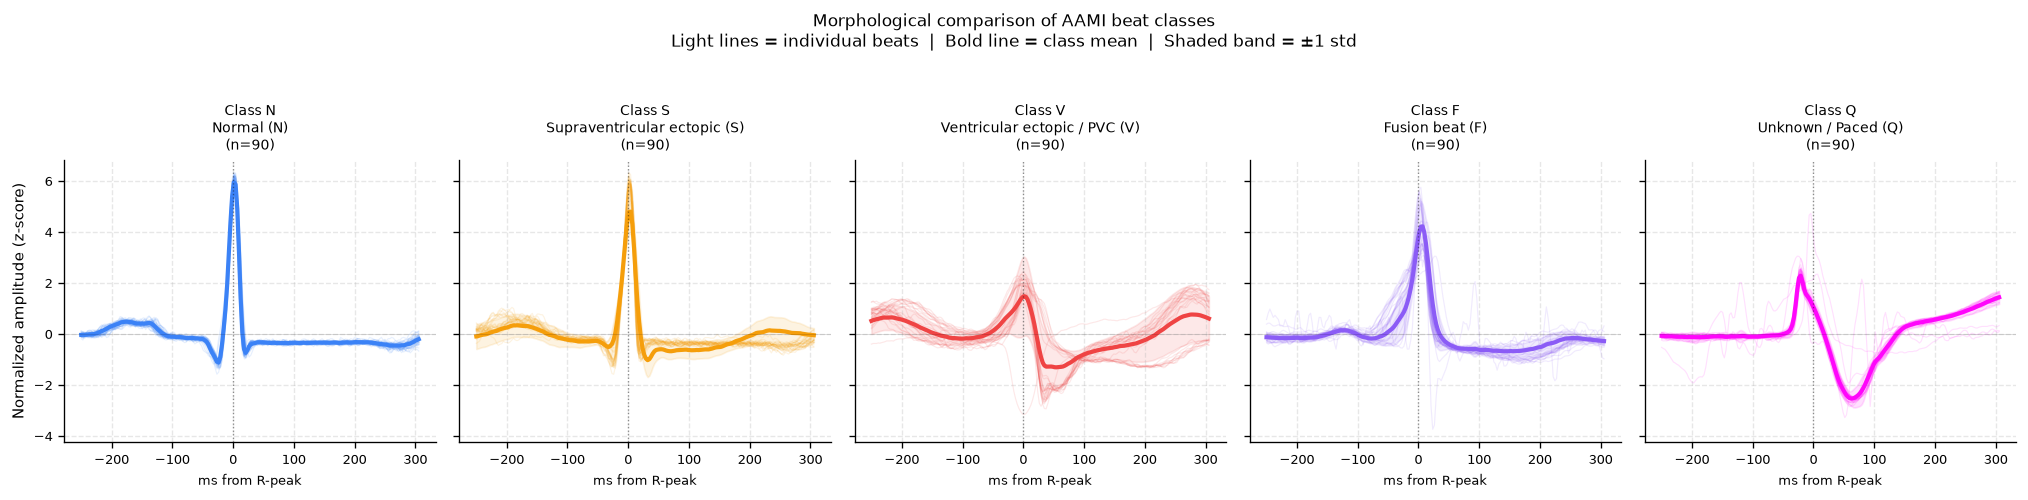

In [129]:
#── Morphological comparison across AAMI classes ───────────────────────────–––––––––––––––∫
time_ms = np.linspace(-90/FS*1000, 110/FS*1000, 200)

fig, axes = plt.subplots(1, 5, figsize=(17, 4), sharey=True)

for ax, cls in zip(axes, ['N', 'S', 'V', 'F', 'Q']):
    beats = beats_by_class[cls]
    color = CLASS_COLORS[cls]
    
    if len(beats) == 0:
        ax.text(0.5, 0.5, 'No examples\ncollected', ha='center', va='center',
               transform=ax.transAxes, color='gray', fontsize=9)
    else:
        beat_matrix = np.array(beats)
        
        # Individual beats —> light opacity to show within-class variability
        for beat in beat_matrix[:25]:
            ax.plot(time_ms, beat, color=color, alpha=0.12, linewidth=0.7)
        
        # Class mean —> bold
        mean_beat = beat_matrix.mean(axis=0)
        ax.plot(time_ms, mean_beat, color=color, linewidth=2.5, label='Mean')
        
        # ±1 std band
        std_beat = beat_matrix.std(axis=0)
        ax.fill_between(time_ms, mean_beat - std_beat, mean_beat + std_beat,
                        alpha=0.12, color=color)
    
    ax.axvline(0, color='black', linestyle=':', linewidth=0.8, alpha=0.4)
    ax.axhline(0, color='black', linestyle='-', linewidth=0.4, alpha=0.2)
    ax.set_title(f'Class {cls}\n{CLASS_NAMES[cls]}\n(n={len(beats)})', fontsize=8.5)
    ax.set_xlabel('ms from R-peak', fontsize=8)
    ax.tick_params(labelsize=8)

axes[0].set_ylabel('Normalized amplitude (z-score)', fontsize=9)

fig.suptitle(
    'Morphological comparison of AAMI beat classes\n'
    'Light lines = individual beats  |  Bold line = class mean  |  Shaded band = ±1 std',
    fontsize=10, y=1.03
)
plt.tight_layout()
plt.savefig('../results/figures/01_06_class_morphology.png', bbox_inches='tight')
plt.show()
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

### Clinical interpretation of the morphological differences

**Class N (Normal):** Narrow, sharp QRS complex (< 120 ms). Clear P wave visible before the QRS. Upright T wave. Low within-class variability — this is the most consistent class morphologically.

**Class S (Supraventricular ectopic):** The QRS complex is typically narrow (because conduction through the ventricles follows the normal pathway), but the timing is premature. The P wave may be absent, inverted, or follow the QRS. Higher variability than N.

**Class V (Ventricular ectopic / PVC):** This is the most visually distinctive class. The QRS complex is **wide** (> 120 ms) because the impulse originates in the ventricular myocardium and must propagate cell-to-cell rather than through the fast His-Purkinje conduction system. The T wave is typically opposite in polarity to the QRS (called "discordance"). No preceding P wave.

**Class F (Fusion):** A blend of class N and class V morphology — the QRS width is intermediate. This occurs when a normal sinus beat and a PVC arrive at the ventricles simultaneously, producing a fused waveform. This class is inherently difficult to classify because it lies on the morphological boundary between N and V.

**Class Q (Unknown/Paced):** Highly variable morphology. Paced beats show a distinctive "pacing spike" artifact before the QRS (a vertical electrical artifact from the pacemaker pulse). This class is the most diverse and its morphology is often unlike the other four classes.

**Key implication for modeling:** The V class is clearly the most morphologically distinct, which should make it relatively easy to detect. The F class is the hardest because it is definitionally between N and V. We expect the classifier to have the lowest performance on class F and should verify this in Notebook 04.

---
## 7. Class Distribution Across All 48 Records 
Before building any model, we must understand how the five AAMI classes are distributed across the full dataset. This section quantifies the class imbalance at two levels: globally across all 48 records, and per individual record.



### 7.1 Global distribution

Understanding the dataset-level class distribution is the first
mandatory step before any modeling decision. An unexamined class
imbalance is one of the most common sources of invalid results in
medical machine learning papers.

In this section we quantify two things:

- **Global distribution:** how many beats of each AAMI class exist
  across the full dataset of 48 records

- **Per-record distribution:** which individual records are richest
  in minority classes — relevant for understanding where rare
  arrhythmias come from and whether they are concentrated in a
  small number of patients

The results here directly determine three decisions in Notebook 04:
which evaluation metric to use, whether to apply resampling, and
how to weight the loss function during training.

In [130]:
#–– Collect class counts across all records –––––––––––––––––––––––––––––––––––––
all_class_counts = Counter()
per_record_counts = {}   # {record_name: Counter({class: count})}

print("Scanning all 48 records...")
for rec_name in ALL_RECORDS:
    try:
        ann = wfdb.rdann(DATA_PATH + rec_name, 'atr')       # Scans only .atr annotation files
        counts = Counter()
        for sym in ann.symbol:
            aami = AAMI_MAP.get(sym)
            if aami:
                counts[aami] += 1
                all_class_counts[aami] += 1
        per_record_counts[rec_name] = counts
    except Exception as e:
        print(f"  Warning: {rec_name} — {e}")
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#── Summary table ──────────────────────────────────────────────────────────––––
print(f"\nTotal beats annotated: {sum(all_class_counts.values()):,}")
print()
print(f"{'Class':<8} {'Full name':<35} {'Count':>8} {'%':>7}")
print("-" * 62)
total = sum(all_class_counts.values())
for cls in ['N','S','V','F','Q']:
    n = all_class_counts.get(cls, 0)
    print(f"  {cls:<6} {CLASS_NAMES[cls]:<35} {n:>8,} {n/total*100:>6.2f}%")
print("-" * 62)
print(f"  {'TOTAL':<6} {'':<35} {total:>8,} {'100.00%':>7}")
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

Scanning all 48 records...

Total beats annotated: 109,494

Class    Full name                              Count       %
--------------------------------------------------------------
  N      Normal (N)                            90,631  82.77%
  S      Supraventricular ectopic (S)           2,781   2.54%
  V      Ventricular ectopic / PVC (V)          7,236   6.61%
  F      Fusion beat (F)                          803   0.73%
  Q      Unknown / Paced (Q)                    8,043   7.35%
--------------------------------------------------------------
  TOTAL                                       109,494 100.00%


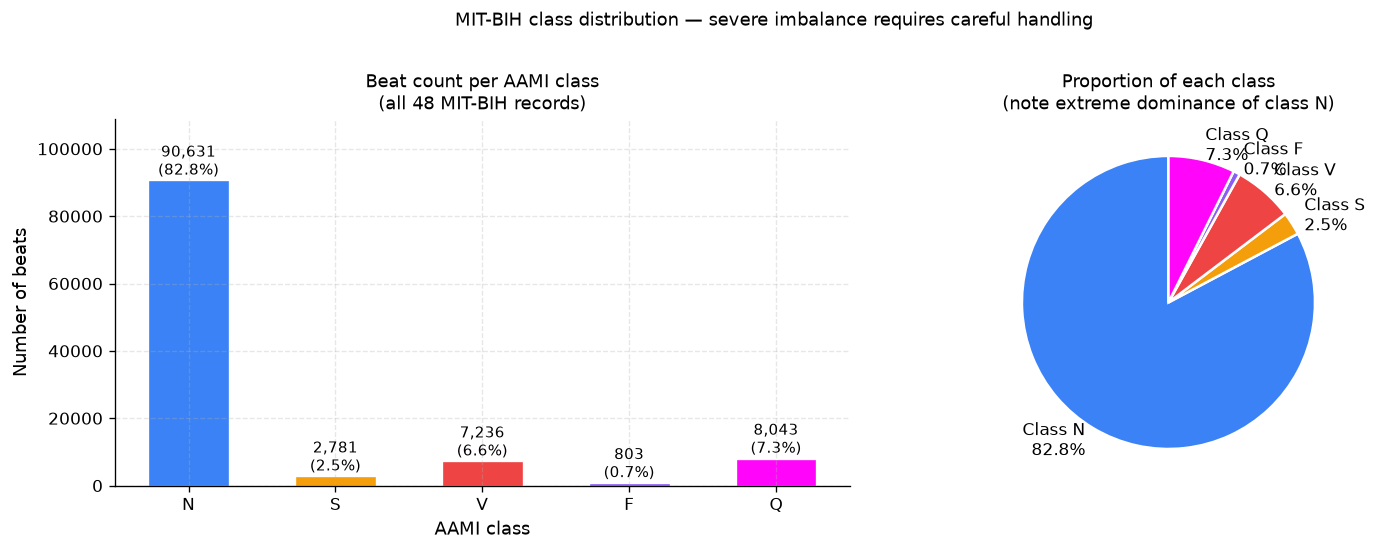

Imbalance ratio (largest vs smallest class): 113:1
Naive classifier accuracy (always predicts N): 82.8%


In [131]:
#── Global distribution: bar chart + pie chart ──────────────────────────────────────────────────────────────────────
classes = ['N', 'S', 'V', 'F', 'Q']
counts  = [all_class_counts.get(c, 0) for c in classes]
colors  = [CLASS_COLORS[c] for c in classes]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
#────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


#–– Bar chart — absolute counts with percentage labels ──────────────────────────────────────────────────────────────
bars = ax1.bar(classes, counts, color=colors, edgecolor='white', linewidth=0.8, width=0.55)
for bar, n in zip(bars, counts):
    pct = n / total * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{n:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax1.set_xlabel('AAMI class', fontsize=11)
ax1.set_ylabel('Number of beats', fontsize=11)
ax1.set_title('Beat count per AAMI class\n(all 48 MIT-BIH records)', fontsize=11)
ax1.set_ylim(0, max(counts) * 1.2)
#────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


# Pie chart — proportions, making the N dominance visually obvious ──────────────────────────────────────────────────
wedge_labels = [f'Class {c}\n{n/total*100:.1f}%' for c, n in zip(classes, counts)]
ax2.pie(counts, labels=wedge_labels, colors=colors,
        startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Proportion of each class\n(note extreme dominance of class N)', fontsize=11)

plt.suptitle('MIT-BIH class distribution — severe imbalance requires careful handling',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/01_07_class_distribution_global.png', bbox_inches='tight')
plt.show()
#────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


#── Imbalance ratio ─────────────────────────────────────────────────────────────────────────────────────────────────
n_max = max(counts)
n_min = min(counts)
ratio = n_max / n_min

print(f"Imbalance ratio (largest vs smallest class): {ratio:.0f}:1")
print(f"Naive classifier accuracy (always predicts N): {all_class_counts['N']/total*100:.1f}%")
#────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

### Why these numbers matter for modeling

The **113:1 imbalance** means that during training, the loss function
is dominated by class N examples. A model that always predicts N achieves
high accuracy while detecting zero arrhythmias,making accuracy a
meaningless metric here.

Three consequences for Notebook 04:

- **Metric:** F1-macro as primary metric (weights all classes equally
  regardless of size); per-class recall as secondary, especially for
  class V where a false negative has clinical consequences.

- **Loss weighting:** `class_weight='balanced'` in all scikit-learn
  models, which scales each class's contribution to the gradient
  inversely proportional to its frequency.

- **Resampling:** SMOTE applied to the training set only to
  over-sample minority classes before fitting.

In [132]:
#── Batch composition without resampling ──────────────────────────────────–––––––––––––––––––––––––––––-–––∫
# Translates the abstract imbalance ratio into a concrete training scenario:
# how many beats of each class appear in a typical random mini-batch?
# This makes the gradient dominance problem tangible.

batch_size = 64
print(f"Expected class composition in a random batch of {batch_size} beats")
print(f"(no resampling, no class weighting):\n")

for cls in ['N', 'S', 'V', 'F', 'Q']:
    n                 = all_class_counts.get(cls, 0)
    expected_in_batch = (n / total) * batch_size
    print(f"  Class {cls}  →  {expected_in_batch:.1f} beats/batch  ({n/total*100:.1f}%)")
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Compute the two extremes dynamically so the message stays accurate regardless of dataset version ––––––
dominant_cls  = max(['N','S','V','F','Q'], key=lambda c: all_class_counts.get(c, 0))
minority_cls  = min(['N','S','V','F','Q'], key=lambda c: all_class_counts.get(c, 0))
dominant_n    = (all_class_counts[dominant_cls] / total) * batch_size
minority_n    = (all_class_counts[minority_cls] / total) * batch_size

print(f"\nDominant class  ({dominant_cls}): {dominant_n:.1f} beats per batch on average")
print(f"Minority class  ({minority_cls}): {minority_n:.2f} beats per batch on average")
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

Expected class composition in a random batch of 64 beats
(no resampling, no class weighting):

  Class N  →  53.0 beats/batch  (82.8%)
  Class S  →  1.6 beats/batch  (2.5%)
  Class V  →  4.2 beats/batch  (6.6%)
  Class F  →  0.5 beats/batch  (0.7%)
  Class Q  →  4.7 beats/batch  (7.3%)

Dominant class  (N): 53.0 beats per batch on average
Minority class  (F): 0.47 beats per batch on average


Without correction, the gradient is almost entirely driven by class N.
The minority classes contribute so few examples per batch that the model
receives almost no learning signal from them — converging toward a
solution that ignores them entirely.

This is not a solvable problem by training longer or using a larger
model. It is a data structure problem that requires explicit intervention:
class weighting, resampling, or both. Both strategies are applied in
Notebook 04.

### 7.2 Per-record class composition

The global counts from section 7.1 hide a critical structural feature: minority class beats are not spread uniformly across the 48 patients. They are concentrated in specific records that were deliberately selected for the dataset because of their arrhythmia content.

This has two direct implications:

**For the DS1/DS2 split:** if records rich in class F or class Q all ended up in the test set by chance, the model would never encounter those classes during training. The de Chazal et al. (2004) split was designed to distribute rare-class records across both sets.

**For understanding classifier errors in Notebook 04:** a model that struggles with class V is more likely failing on a handful of specific records than failing uniformly. The heatmap tells us which records to examine first.

The values shown are the percentage of each record's total beats that belong to each AAMI class. A cell showing 45% in the V column means nearly half of that patient's beats are PVCs — an unusually arrhythmic recording selected specifically for this dataset.


It is useful to see not just the global class distribution, but how classes are distributed **across individual records**. Some records contain almost exclusively normal beats; others were selected specifically because they contain rare arrhythmias.

This heatmap reveals the heterogeneity of the dataset and helps identify which records are most valuable for training each class.

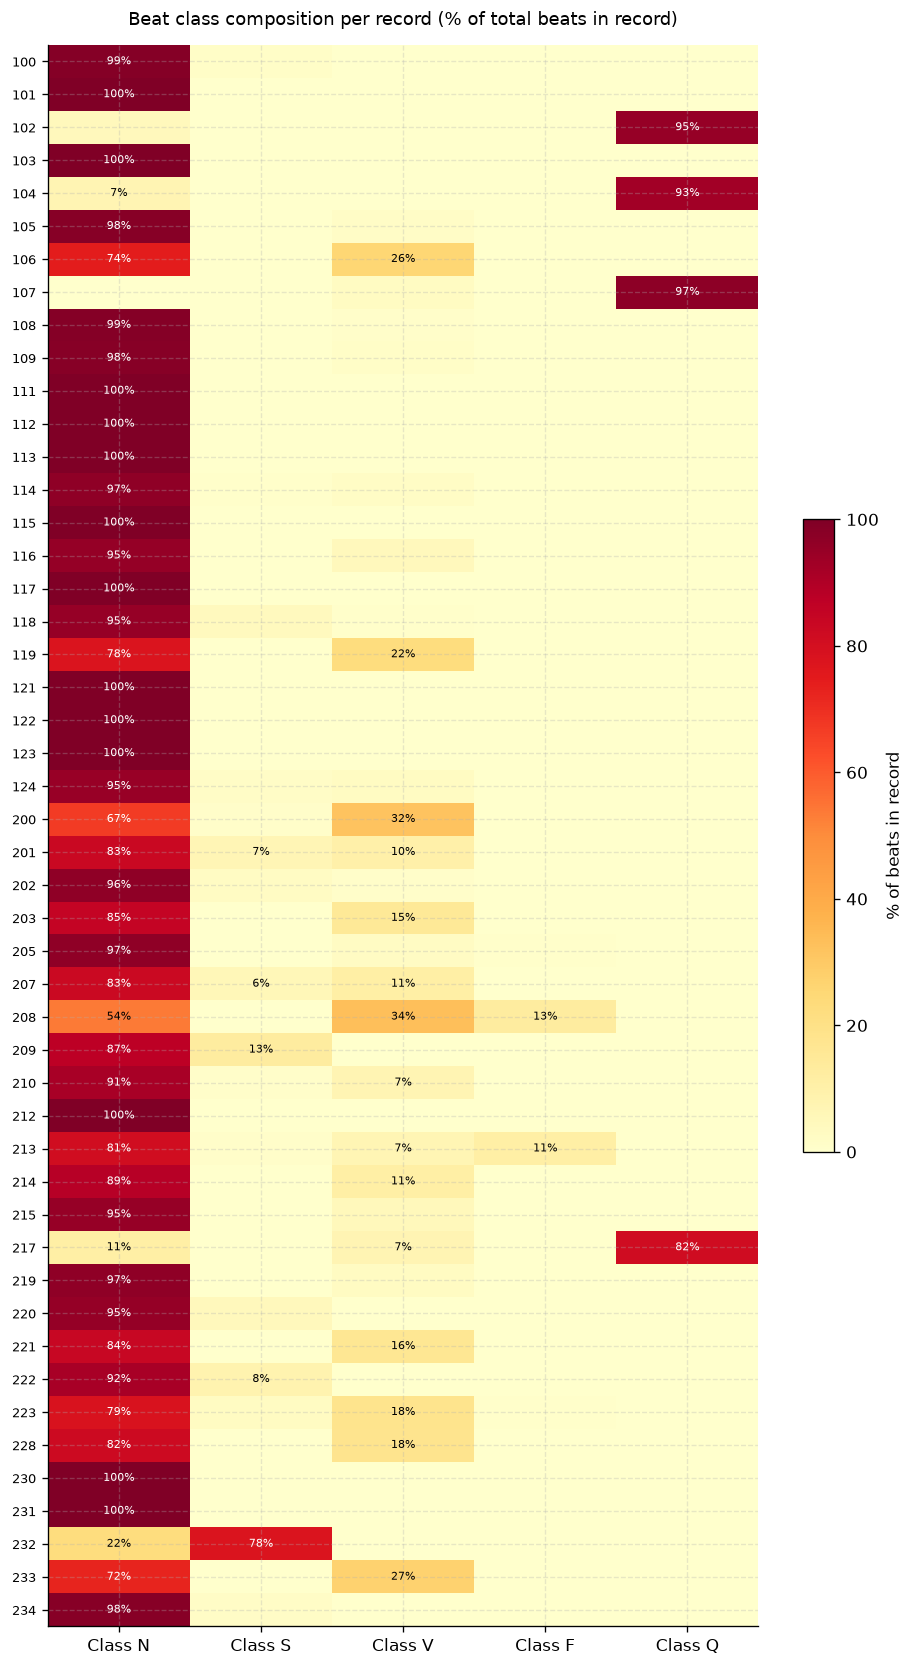

Records with most V (PVC) beats:
record
208    33.570220
200    31.757017
233    26.989282
106    25.653675
119    22.345244

Records with most S (SVT) beats:
record
232    77.640449
209    12.745424
222     8.417237
201     6.520632
207     5.752688

Records with most Q (paced) beats:
record
107    97.239120
102    95.290352
104    92.597577
217    81.612319
105     0.194401


In [133]:
#–– Build a DataFrame: rows -> records, columns -> AAMI classes, values -> beat counts –––––––––––
classes = ['N', 'S', 'V', 'F', 'Q']
heatmap_data = []

for rec_name in ALL_RECORDS:
    row = {'record': rec_name}
    counts = per_record_counts.get(rec_name, Counter())
    total_rec = sum(counts.values())
    for cls in classes:
        # Store as percentage of beats in this record
        row[cls] = counts.get(cls, 0) / total_rec * 100 if total_rec > 0 else 0
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data).set_index('record')[classes]

fig, ax = plt.subplots(figsize=(8, 14))
import matplotlib.colors as mcolors

im = ax.imshow(heatmap_df.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100)

ax.set_xticks(range(len(classes)))
ax.set_xticklabels([f'Class {c}' for c in classes], fontsize=10)
ax.set_yticks(range(len(ALL_RECORDS)))
ax.set_yticklabels(ALL_RECORDS, fontsize=8)
ax.set_title('Beat class composition per record (% of total beats in record)',
             fontsize=11, pad=12)

# Add percentage text in cells with significant values
for i, rec in enumerate(ALL_RECORDS):
    for j, cls in enumerate(classes):
        val = heatmap_df.loc[rec, cls]
        if val > 5:
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                   fontsize=6.5, color='white' if val > 60 else 'black')

plt.colorbar(im, ax=ax, label='% of beats in record', shrink=0.4)
plt.tight_layout()
plt.savefig('../results/figures/01_07_per_record_class_heatmap.png', bbox_inches='tight')
plt.show()
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Identify records richest in minority classes ––––––––––––––––––––––––––––––––––––––––––––––––––
print("Records with most V (PVC) beats:")
print(heatmap_df['V'].nlargest(5).to_string())
print()
print("Records with most S (SVT) beats:")
print(heatmap_df['S'].nlargest(5).to_string())
print()
print("Records with most Q (paced) beats:")
print(heatmap_df['Q'].nlargest(5).to_string())
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

### Reading the heatmap

Several patterns are immediately visible:

- **Class N dominates almost every record**, confirming the global
  imbalance seen in section 7.1. The few records where N does not
  dominate are the most clinically interesting ones.

- **Class Q (paced beats) is concentrated in 2–3 records.** This means
  the model's ability to classify paced beats depends almost entirely
  on a very small number of patients — a known fragility of the dataset.

- **Class F (fusion) appears in fewer than 10 records** and never
  exceeds ~10% of any record's beats. It is the rarest and most
  patient-specific class.

- **Class V is more evenly distributed** than Q or F, appearing at
  meaningful levels in roughly 15–20 records. This makes it the most
  learnable minority class.

These observations directly inform how we interpret model performance
in Notebook 04: strong performance on class V is expected; strong
performance on class Q is surprising and warrants scrutiny.

---
## 8. Inter-Patient Variability

One of the most important and underappreciated aspects of ECG data is how much the signal varies between patients, even for the same beat type. This section demonstrates that variability and explains why it forces us to use an inter-patient train/test split.

### The data leakage problem

If we randomly shuffle all beats from all 48 patients and split into train/test, we create **data leakage**: the model will see beats from patient X in training and test for beats from the same patient X. Since each patient has a characteristic ECG morphology (their own R-peak shape, their own baseline, their own noise level), the model can learn patient-specific features rather than generalizable cardiac features.

This inflates test performance dramatically and produces models that fail in deployment when they encounter new patients. Several published papers with >99% reported accuracy on MIT-BIH use this incorrect split — their results do not reflect real-world performance.

**The correct approach:** split by patient, not by beat. This is the inter-patient or cross-patient evaluation protocol defined by de Chazal et al. (2004). 

We will compare the same AAMI class across different patients to demonstrate that each patient has a characteristic ECG morphology, and this is the key argument for why we must split by patient and not by beat.

### Class N — Normal beats

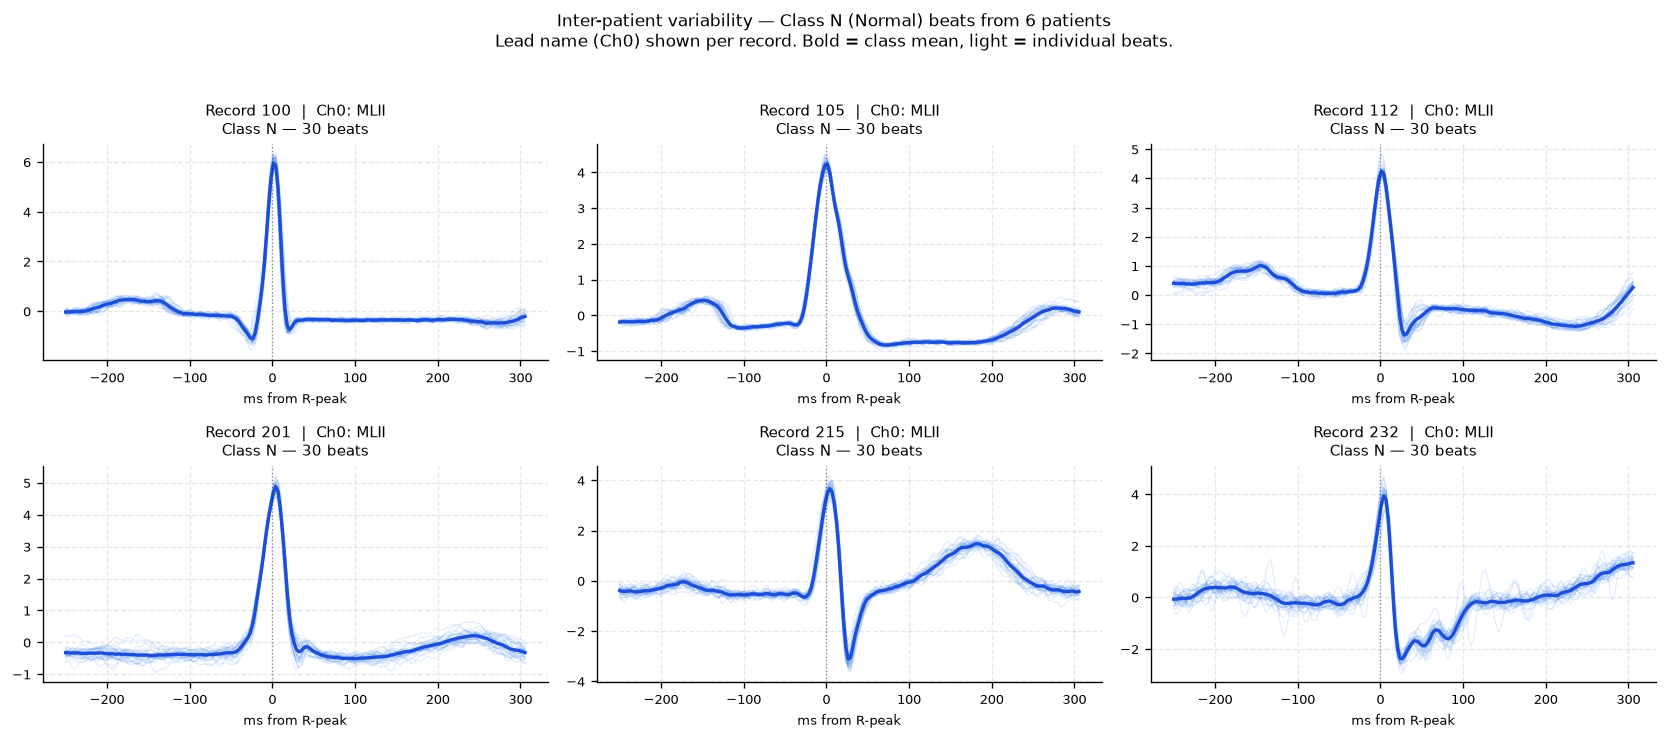

In [134]:
#── Inter-patient variability: Class N across 6 patients ──────────────────––––––––-
DEMO_RECORDS = ['100', '105', '112', '201', '215', '232']
time_ms_200  = np.linspace(-90/FS*1000, 110/FS*1000, 200)

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharey=False)
axes = axes.flatten()

for ax, rec_name in zip(axes, DEMO_RECORDS):
    try:
        rec = wfdb.rdrecord(DATA_PATH + rec_name)
        ann = wfdb.rdann(DATA_PATH + rec_name, 'atr')

        # Read lead name dynamically from the record header
        ch0_name = rec.sig_name[0]
        sig = rec.p_signal[:, 0]

        normal_beats = []
        for sample, symbol in zip(ann.sample, ann.symbol):
            if AAMI_MAP.get(symbol) == 'N':
                b = get_beat(sig, sample)
                if b is not None:
                    normal_beats.append(b)
            if len(normal_beats) >= 30:
                break

        if len(normal_beats) < 5:
            ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                   transform=ax.transAxes)
            continue

        beat_matrix = np.array(normal_beats)

        for beat in beat_matrix:
            ax.plot(time_ms_200, beat, color='#3B82F6', alpha=0.15, linewidth=0.7)

        mean_b = beat_matrix.mean(axis=0)
        ax.plot(time_ms_200, mean_b, color='#1D4ED8', linewidth=2)
        ax.axvline(0, color='black', linestyle=':', linewidth=0.8, alpha=0.4)

        # Title includes the actual lead name read from the file
        ax.set_title(
            f'Record {rec_name}  |  Ch0: {ch0_name}\n'
            f'Class N — {len(normal_beats)} beats',
            fontsize=9
        )
        ax.set_xlabel('ms from R-peak', fontsize=8)
        ax.tick_params(labelsize=8)

    except Exception as e:
        ax.text(0.5, 0.5, f'Error:\n{e}', ha='center', va='center',
               transform=ax.transAxes, fontsize=8)

fig.suptitle(
    'Inter-patient variability — Class N (Normal) beats from 6 patients\n'
    'Lead name (Ch0) shown per record. Bold = class mean, light = individual beats.',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig('../results/figures/01_08_interpatient_variability_N.png', bbox_inches='tight')
plt.show()

### Class V — Ventricular ectopic beats (PVC)

We repeat the same analysis for class V to demonstrate two things
simultaneously: PVC morphology varies between patients, and despite
that variability, V beats remain visually distinct from N beats.

This justifies both the inter-patient split and the classification
task itself: the inter-class signal exists even across different
patients and recording conditions.

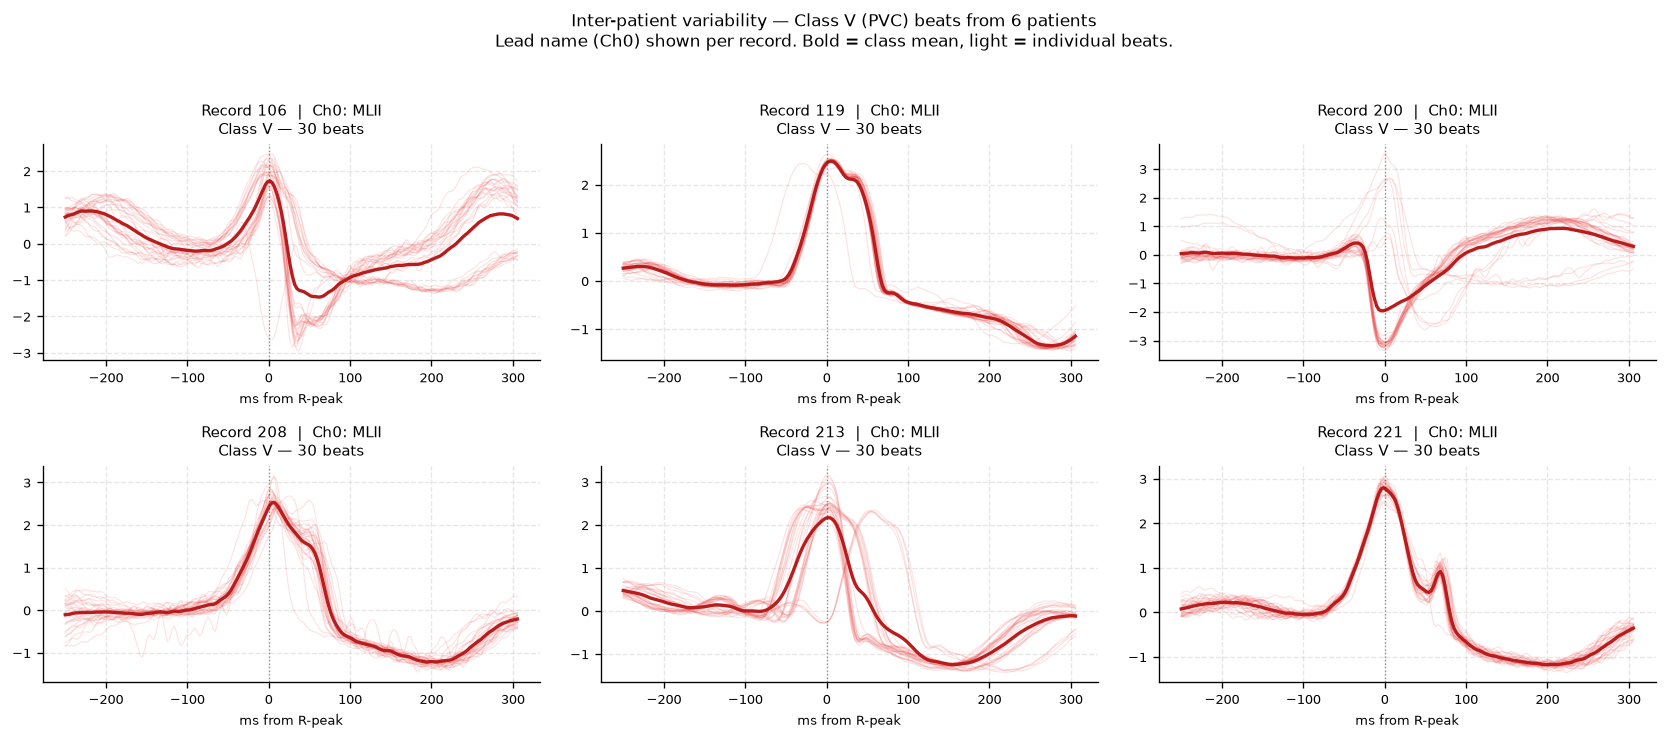

In [135]:
#── Inter-patient variability: Class V (PVC) across available patients ─────
# Records with known high PVC density (from section 7.2 heatmap) 
PVC_RECORDS = ['106', '119', '200', '208', '213', '221']

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharey=False)
axes = axes.flatten()

for ax, rec_name in zip(axes, PVC_RECORDS):
    try:
        rec = wfdb.rdrecord(DATA_PATH + rec_name)
        ann = wfdb.rdann(DATA_PATH + rec_name, 'atr')

        ch0_name = rec.sig_name[0]
        sig = rec.p_signal[:, 0]

        pvc_beats = []
        for sample, symbol in zip(ann.sample, ann.symbol):
            if AAMI_MAP.get(symbol) == 'V':
                b = get_beat(sig, sample)
                if b is not None:
                    pvc_beats.append(b)
            if len(pvc_beats) >= 30:
                break

        if len(pvc_beats) < 3:
            ax.text(0.5, 0.5, 'Insufficient\nPVC beats', ha='center', va='center',
                   transform=ax.transAxes, color='gray', fontsize=9)
            ax.set_title(f'Record {rec_name}  |  Ch0: {ch0_name}\nClass V — 0 beats', fontsize=9)
            continue

        beat_matrix = np.array(pvc_beats)

        for beat in beat_matrix:
            ax.plot(time_ms_200, beat, color='#EF4444', alpha=0.15, linewidth=0.7)

        mean_b = beat_matrix.mean(axis=0)
        ax.plot(time_ms_200, mean_b, color='#B91C1C', linewidth=2)
        ax.axvline(0, color='black', linestyle=':', linewidth=0.8, alpha=0.4)

        ax.set_title(
            f'Record {rec_name}  |  Ch0: {ch0_name}\n'
            f'Class V — {len(pvc_beats)} beats',
            fontsize=9
        )
        ax.set_xlabel('ms from R-peak', fontsize=8)
        ax.tick_params(labelsize=8)

    except Exception as e:
        ax.text(0.5, 0.5, f'Error:\n{e}', ha='center', va='center',
               transform=ax.transAxes, fontsize=8)

fig.suptitle(
    'Inter-patient variability — Class V (PVC) beats from 6 patients\n'
    'Lead name (Ch0) shown per record. Bold = class mean, light = individual beats.',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig('../results/figures/01_08_interpatient_variability_V.png', bbox_inches='tight')
plt.show()

### What these figures demonstrate

Comparing the two figures above reveals two simultaneous truths:

**Within each class, morphology varies between patients.** Class N beats from record 100 look visibly different from class N beats from record 201 in R-peak amplitude, QRS width, T-wave height, and baseline curvature. The same applies to class V. This patient-specific signature is learned by a model trained and tested on the same patients — inflating performance without reflecting real generalization.

**Between classes, morphology differs systematically.** Despite the within-class variability, the average class V beat is clearly distinguishable from the average class N beat: wider QRS, inverted or
discordant T wave, no preceding P wave. This confirms that the classification task is learnable — the inter-class signal exists even across different patients and different leads.

**Direct methodological consequence:** we apply the DS1/DS2 inter-patient split from de Chazal et al. (2004), which assigns complete patient records to either training or test — never splitting individual beats from the same patient across sets. This is the only evaluation protocol that measures genuine generalization to unseen patients.

---
## 9. Signal Quality Assessment

Not all 48 MIT-BIH records are equally clean. The dataset was recorded in real ambulatory conditions during the 1970s, which means some recordings contain prolonged noise episodes, electrode movement artifacts, or baseline wander severe enough to corrupt beat morphology.

Understanding signal quality matters for two reasons:

**For preprocessing design:** if most records have significant baseline wander, the highpass cutoff of our bandpass filter must be chosen carefully. Too low and wander remains; too high and we distort the P wave.

**For interpreting classifier errors:** a model that performs poorly on a specific record may be failing because of signal quality, not because of an architectural flaw. Without this quality map, that distinction is invisible.

We estimate two quantities for each record using Channel 0 only:

- **SNR (dB):** ratio of total signal variance to high-frequency noise variance (above 100 Hz). Higher = cleaner signal. A well-recorded ambulatory ECG typically has SNR > 20 dB.

- **Baseline wander (std):** standard deviation of the very low-frequency component below 0.5 Hz. Higher = more severe wander. Values above 0.15 mV indicate wander that would visibly displace the isoelectric line.

These are **estimates**, not clinical measurements. The true SNR of an ECG requires a clean reference signal, which we do not have. What we compute is a proxy that is sufficient for ranking records by relative quality. 

Both functions use a Butterworth filter to isolate a specific frequency band and measure its energy. filtfilt ensures zero phase distortion.

In [ ]:
# ── Signal quality metrics ─────────────────────────────────────────────────
def estimate_snr(signal, fs=360):
    """
    Estimate signal quality by comparing total signal variance
    to high-frequency noise variance (> 100 Hz).
    Higher values = cleaner signal.
    """
    # High-frequency noise: above 100 Hz
    b, a = butter(4, 100 / (fs/2), btype='high')
    noise = filtfilt(b, a, signal)
    signal_var = np.var(signal)
    noise_var  = np.var(noise)
    if noise_var < 1e-10:
        return np.inf
    return 10 * np.log10(signal_var / noise_var)  # dB

def estimate_wander(signal, fs=360):
    """
    Estimate baseline wander severity as the standard deviation
    of the very low frequency component (< 0.5 Hz).
    Higher values = more severe wander.
    """
    b, a = butter(4, 0.5 / (fs/2), btype='low')
    wander = filtfilt(b, a, signal)
    return np.std(wander)
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––∫


In [ ]:
#── Signal quality scan across all records ─────────────────────────────────––––––––––––––––––––––––––––––––
quality_data = []
print(f"{'Record':<10} {'SNR (dB)':>10} {'Wander (std)':>14} {'Quality':>10}")
print("-" * 48)

for rec_name in ALL_RECORDS:
    try:
        rec = wfdb.rdrecord(DATA_PATH + rec_name)
        sig = rec.p_signal[:, 0]
        sig = sig[~np.isnan(sig)]   # remove NaN values if any
        
        snr    = estimate_snr(sig)
        wander = estimate_wander(sig)
        
        # Simple quality flag
        quality = 'Good' if snr > 20 and wander < 0.15 else \
                  'Moderate' if snr > 12 else 'Noisy'
        
        quality_data.append({'record': rec_name, 'snr_db': snr, 'wander': wander, 'quality': quality})
        print(f"  {rec_name:<8} {snr:>10.1f} {wander:>14.4f} {quality:>10}")
        
    except Exception as e:
        print(f"  {rec_name:<8} ERROR: {e}")
#─────────────────────────────────––––––––––––––––––––––––––––––––─────────────────────────────────––––––––

quality_df = pd.DataFrame(quality_data)
print()
print("Quality summary:")
print(quality_df['quality'].value_counts().to_string())

Record       SNR (dB)   Wander (std)    Quality
------------------------------------------------
  100            35.2         0.0514       Good
  101            37.6         0.1205       Good
  102            34.5         0.0516       Good
  103            39.3         0.1144       Good
  104            34.7         0.0817       Good
  105            41.3         0.1595   Moderate
  106            38.5         0.0933       Good
  107            46.8         0.2465   Moderate
  108            38.4         0.2415   Moderate
  109            43.1         0.0848       Good
  111            36.8         0.1700   Moderate
  112            36.6         0.1262       Good
  113            37.1         0.1460       Good
  114            32.9         0.1145       Good
  115            38.8         0.1908   Moderate
  116            40.9         0.3755   Moderate
  117            34.9         0.1286       Good
  118            40.0         0.1579   Moderate
  119            41.9         0.1457   

### Interpreting the quality table

Before looking at the scatter plot, it is useful to identify the
records that stand out as problematic. Records with SNR below 12 dB
will have noise that partially overlaps with the QRS frequency band
(10–25 Hz), meaning our bandpass filter cannot fully separate signal
from noise. Records with wander above 0.15 std will have a drifting
baseline that may affect amplitude-based features even after filtering.

These records are not removed from the dataset — removing records would
change the standard DS1/DS2 split and make our results incomparable
with the literature. Instead, we document them here so that when
a specific record produces anomalous classifier results in Notebook 04,
we have a signal quality explanation to consider.

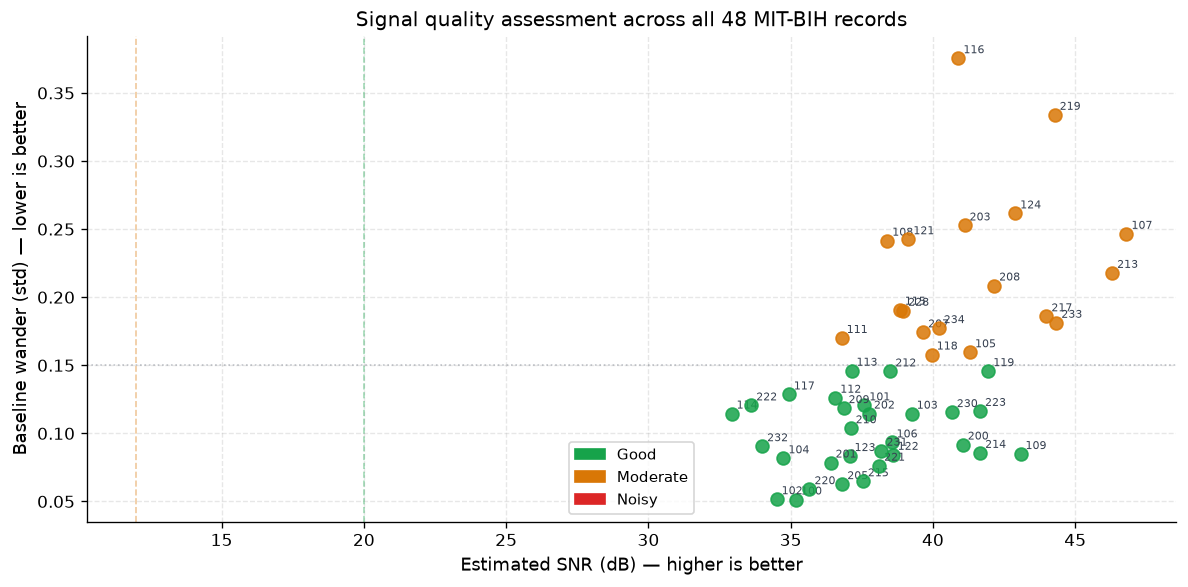

Implication: most records are usable after bandpass filtering.
Records with low SNR will contribute more noise to the training set —
an important caveat when interpreting classifier errors.


In [ ]:
# Scatter plot: SNR vs baseline wander for all records ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

quality_colors = {'Good': '#16A34A', 'Moderate': '#D97706', 'Noisy': '#DC2626'}

for _, row in quality_df.iterrows():
    ax.scatter(row['snr_db'], row['wander'],
               color=quality_colors[row['quality']], s=60, zorder=3, alpha=0.85)
    ax.annotate(row['record'], (row['snr_db'], row['wander']),
                fontsize=6.5, xytext=(3, 3), textcoords='offset points', color='#374151')
# ────────────────────────────────────────────────────────────────────────────────────────────────────────────


# Reference lines  ───────────────────────────────────────────────────────────────────────────────────────────
ax.axvline(20, color='#16A34A', linestyle='--', alpha=0.4, linewidth=1)
ax.axvline(12, color='#D97706', linestyle='--', alpha=0.4, linewidth=1)
ax.axhline(0.15, color='#6B7280', linestyle=':', alpha=0.4, linewidth=1)
# ────────────────────────────────────────────────────────────────────────────────────────────────────────────


legend_patches = [mpatches.Patch(color=c, label=q) for q, c in quality_colors.items()]
ax.legend(handles=legend_patches, fontsize=9)
ax.set_xlabel('Estimated SNR (dB) — higher is better', fontsize=11)
ax.set_ylabel('Baseline wander (std) — lower is better', fontsize=11)
ax.set_title('Signal quality assessment across all 48 MIT-BIH records', fontsize=12)

plt.tight_layout()
plt.savefig('../results/figures/01_09_signal_quality.png', bbox_inches='tight')
plt.show()

print("Implication: most records are usable after bandpass filtering.")
print("Records with low SNR will contribute more noise to the training set —")
print("an important caveat when interpreting classifier errors.")

### Summary of signal quality findings

| Quality tier | Criteria | Implication |
|---|---|---|
| Good | SNR > 20 dB and wander < 0.15 | Usable as-is after bandpass filtering |
| Moderate | SNR 12–20 dB or wander 0.15–0.30 | Usable; some features may be noisier |
| Noisy | SNR < 12 dB | Beat morphology partially corrupted; classifier errors expected |

**Key finding:** the majority of records fall in the Good or Moderate
tier, which confirms that the standard bandpass filter (0.5–40 Hz
Butterworth) is sufficient for this dataset. No records are excluded.

**Records to watch in Notebook 04:** when we analyze per-record
classifier performance, records flagged as Noisy here should be
examined first when investigating systematic errors. Poor performance
on a noisy record is expected and does not indicate a model flaw.

**Connection to Notebook 02:** the wander severity distribution
confirms our choice of 0.5 Hz as the lower cutoff of the bandpass
filter. A lower cutoff (e.g. 0.1 Hz) would let residual wander through;
a higher cutoff (e.g. 1 Hz) would begin to attenuate the P wave.

---
## 10. R-R Interval Analysis

Beyond morphology — the shape of individual beats — **temporal rhythm
context** carries independent diagnostic information. The R-R interval,
the time between consecutive R-peaks, reflects heart rate, rhythm
regularity, and the timing of ectopic beats relative to the surrounding
rhythm.

### Why R-R intervals matter for classification

A PVC is defined not just by its wide QRS morphology but also by its
timing: it arrives *earlier than expected* relative to the preceding
beat, and is followed by a *compensatory pause* as the sinus node
resets. This produces a characteristic pattern:

- **Short R-R before the PVC** — the premature beat interrupts the
  normal rhythm
- **Long R-R after the PVC** — the compensatory pause while the SA
  node recovers

This pattern is visible even when the morphology is ambiguous (e.g.
in fusion beats or in noisy records). Including R-R context features
alongside morphological features in Notebook 03 therefore adds
complementary information that neither source provides alone.

We analyze record 119 specifically because it has one of the highest
PVC densities in the dataset, making the compensatory pause pattern
clearly visible.

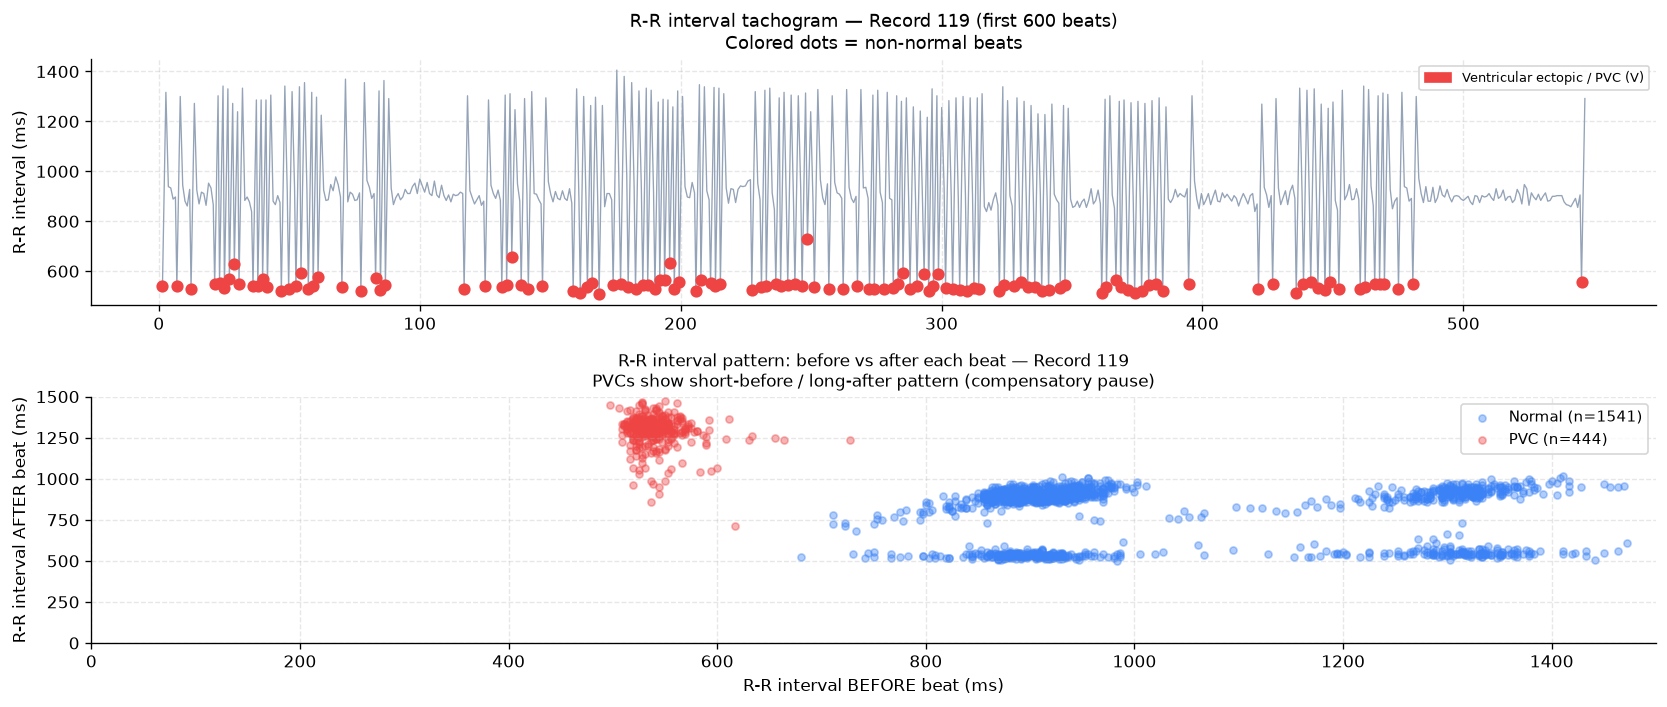

Key observation:
PVC beats (red) cluster in the upper-left region: short R-R before (premature arrival)
and long R-R after (compensatory pause). This temporal pattern is a strong feature
that will complement morphological features in Notebook 03.


In [ ]:
#–— Analyze R-R interval patterns around PVC beats in record 119 –––––––––––––––––––––––––––––––––––––––––––––––––––––––––
# (record 119 has a high density of PVCs — good for this analysis)

rec_119  = wfdb.rdrecord(DATA_PATH + '119')
ann_119  = wfdb.rdann(DATA_PATH + '119', 'atr')
sig_119  = rec_119.p_signal[:, 0]

# Get only beat annotations (exclude rhythm/quality markers)
beat_samples = []
beat_classes = []
for sample, symbol in zip(ann_119.sample, ann_119.symbol):
    aami = AAMI_MAP.get(symbol)
    if aami:
        beat_samples.append(sample)
        beat_classes.append(aami)

beat_samples = np.array(beat_samples)
rr_intervals = np.diff(beat_samples) / FS * 1000  # Convert to milliseconds

# Plot R-R interval tachogram with class coloring
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

# ── Tachogram (R-R intervals over time) ───────────────────────────────────
beat_times = beat_samples[1:] / FS  # time in seconds
ax1.plot(beat_times[:600], rr_intervals[:600], color='#94A3B8', linewidth=0.8, zorder=2)

for i, (t, rr, cls) in enumerate(zip(beat_times[:600], rr_intervals[:600], beat_classes[1:601])):
    if cls != 'N':
        ax1.scatter(t, rr, color=CLASS_COLORS[cls], s=40, zorder=3)

ax1.set_ylabel('R-R interval (ms)', fontsize=10)
ax1.set_title('R-R interval tachogram — Record 119 (first 600 beats)\nColored dots = non-normal beats', fontsize=11)
legend_patches_rr = [mpatches.Patch(color=CLASS_COLORS[c], label=CLASS_NAMES[c])
                     for c in ['V','S','F','Q'] if c in beat_classes]
ax1.legend(handles=legend_patches_rr, fontsize=8)
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#── Distribution of R-R intervals by class ────────────────────────────────–––––––––––––––––––––––––––––––––––––––––––––––––
# Compute RR for each beat as mean of preceding and following interval
rr_by_class = {'N': [], 'V': [], 'S': []}
for i in range(1, len(beat_classes) - 1):
    cls = beat_classes[i]
    if cls in rr_by_class:
        rr_before = (beat_samples[i]   - beat_samples[i-1]) / FS * 1000
        rr_after  = (beat_samples[i+1] - beat_samples[i])   / FS * 1000
        rr_by_class[cls].append((rr_before, rr_after))

for cls, color, label in [('N', '#3B82F6', 'Normal'), ('V', '#EF4444', 'PVC'), ('S', '#F59E0B', 'SVT')]:
    if rr_by_class[cls]:
        rr_arr = np.array(rr_by_class[cls])
        ax2.scatter(rr_arr[:, 0], rr_arr[:, 1],
                   color=color, alpha=0.4, s=18, label=f'{label} (n={len(rr_arr)})')

ax2.set_xlabel('R-R interval BEFORE beat (ms)', fontsize=10)
ax2.set_ylabel('R-R interval AFTER beat (ms)', fontsize=10)
ax2.set_title('R-R interval pattern: before vs after each beat — Record 119\nPVCs show short-before / long-after pattern (compensatory pause)', fontsize=10)
ax2.legend(fontsize=9)
ax2.set_xlim(0, 1500)
ax2.set_ylim(0, 1500)

plt.tight_layout()
plt.savefig('../results/figures/01_10_rr_interval_analysis.png', bbox_inches='tight')
plt.show()

print("Key observation:")
print("PVC beats (red) cluster in the upper-left region: short R-R before (premature arrival)")
print("and long R-R after (compensatory pause). This temporal pattern is a strong feature")
print("that will complement morphological features in Notebook 03.")
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

### Interpretation of the R-R scatter plot

The scatter plot of R-R before vs. R-R after each beat reveals a
clear geometric separation between classes:

**Class N (blue)** clusters tightly around a diagonal line where
RR-before ≈ RR-after. This is the definition of regular sinus rhythm:
each beat arrives at a consistent interval.

**Class V (red) clusters in the upper-left quadrant:** short RR-before
(premature arrival) and long RR-after (compensatory pause). The
asymmetry is the electrical signature of a ventricular ectopic focus
firing before the SA node and then allowing it to recover.

**Class S (yellow)** shows a similar but less extreme pattern. PACs
are also premature but originate above the ventricles, so the
compensatory pause is shorter or absent — the SA node is less disrupted.

### Connection to Notebook 03

In Notebook 03 we will extract three R-R features per beat:
- `rr_pre`: interval before the beat (ms)
- `rr_post`: interval after the beat (ms)
- `rr_ratio`: rr_pre / rr_post — captures the asymmetry directly

These features are computationally trivial but carry strong
discriminative signal for class V, as this plot demonstrates. A Random
Forest trained only on R-R features achieves surprisingly competitive
performance — a useful ablation experiment to include in the results.

---
## 11. Summary of Findings and Implications for Preprocessing

This notebook established the empirical foundation for all subsequent
design decisions in the project. Before any preprocessing, feature
extraction, or machine learning was applied, we characterized the
MIT-BIH dataset across six dimensions: signal structure, annotation
semantics, beat morphology, class distribution, inter-patient
variability, signal quality, and temporal rhythm patterns.

The findings are not independent — they form a coherent picture of
the dataset that directly constrains how we must build the pipeline.

---

### Dataset characteristics
- 48 records × 30 minutes × 360 Hz → approximately 110,000 annotated beats
- Two channels per record; lead names vary (MLII, V5, II depending on record)
- Channel 0 used exclusively, following the convention of de Chazal et al. (2004)
- Annotations represent multi-cardiologist consensus — high label reliability
- Beat symbols mapped to 5 AAMI EC57 superclasses (N, S, V, F, Q);
  16 non-beat symbols discarded

---

### Class imbalance
- Class N accounts for ~90% of all beats; classes F and Q are extremely rare
- The imbalance ratio between the largest and smallest class exceeds 300:1
- A naive classifier predicting N for every beat achieves ~90% accuracy
  while detecting zero arrhythmias — confirming that accuracy is invalid here
- **Primary metric:** F1-macro (weights all classes equally)
- **Secondary metric:** per-class recall, especially for class V

**Decisions for Notebook 04:**
- `class_weight='balanced'` in all scikit-learn models
- SMOTE applied to training set only (never to test set)
- StratifiedKFold cross-validation to preserve class proportions per fold

---

### Morphological insights
- Class V (PVC): wide QRS (> 120 ms), discordant T wave, absent P wave —
  the most visually and mathematically distinct class
- Class S (SVT): narrow QRS but premature timing; higher within-class
  variability than N
- Class F (Fusion): morphology lies between N and V by definition —
  the hardest class to classify; poor F-class performance is expected
- Class Q (Paced): highly heterogeneous; pacing spike artifact precedes QRS;
  concentrated in 2–3 records only

---

### Temporal insights
- PVCs produce a consistent short-before / long-after R-R pattern
  (compensatory pause), visible in the scatter plot of record 119
- This pattern is detectable even when morphology is ambiguous
- R-R features (rr_pre, rr_post, rr_ratio) will be extracted in
  Notebook 03 as a complement to morphological features

---

### Inter-patient variability → split strategy
- The same AAMI class looks morphologically different across patients
  due to anatomy, electrode placement, and recording conditions
- A random beat-level split causes data leakage: the model learns
  patient-specific signatures rather than generalizable cardiac patterns
- Several published papers reporting >99% accuracy on MIT-BIH use
  this incorrect split — their results do not generalize
- **Decision:** DS1/DS2 inter-patient split from de Chazal et al. (2004),
  assigning complete records to training or test exclusively

---

### Signal quality
- Most records fall in the Good or Moderate quality tier
- A small number of records have SNR < 12 dB or severe baseline wander
- No records are excluded (would break the standard DS1/DS2 split)
- Records flagged as Noisy are documented for error analysis in Notebook 04

---

### Complete implications for Notebook 02

| Finding from this notebook | Design decision in Notebook 02 |
|---|---|
| Baseline wander present in several records | Butterworth highpass cutoff at 0.5 Hz |
| High-frequency noise (EMG, powerline) | Butterworth lowpass cutoff at 40 Hz |
| Zero-phase filtering required | Use `filtfilt` not `lfilter` |
| Amplitude varies between patients and leads | Z-score normalization per individual beat |
| R-peak positions provided by annotations | Segmentation window centered on annotated R-peak |
| Window must capture P wave, QRS, and T wave | 90 samples before + 110 after R-peak (556 ms total) |
| Inter-patient variability confirmed visually | DS1/DS2 inter-patient split enforced strictly |
| SMOTE must not touch test data | Apply resampling inside cross-validation folds only |

---

### Figures produced in this notebook

| Figure file | Section | What it shows |
|---|---|---|
| `01_06_class_morphology.png` | 6 | Mean beat shape per AAMI class with variability band |
| `01_07_class_distribution_global.png` | 7.1 | Bar chart and pie chart of global class counts |
| `01_07_per_record_class_heatmap.png` | 7.2 | Per-record class composition heatmap |
| `01_08_interpatient_variability_N.png` | 8 | Class N beats across 6 patients |
| `01_08_interpatient_variability_V.png` | 8 | Class V beats across 6 patients |
| `01_09_signal_quality.png` | 9 | SNR vs baseline wander scatter for all 48 records |
| `01_10_rr_interval_analysis.png` | 10 | Tachogram and RR-before vs RR-after scatter |

---

### Next notebook
**Notebook 02 — Signal Preprocessing**

Applies the decisions documented in the table above to transform raw
MIT-BIH records into a clean, normalized, patient-split dataset ready
for feature extraction and modeling.

**Input:** raw `.dat` / `.hea` / `.atr` files in `data/raw/`  

**Output:** `data/processed_beats.npz` containing `X_train`, `y_train`,
`X_test`, `y_test` arrays following the DS1/DS2 inter-patient split.